# Sonification of Mach Zehnder Interferometer

Olivia Watt | Virginia Tech | Spring 2026

### Setup
First, run the following command to install the necessary modules in a Python virtual environment
```
python3 -m pip install -r requirements.txt
```

### Imports

In [24]:
# first install perceval using ```pip install perceval-quandela```
import perceval as pcvl
import perceval.components as comp

from perceval.backends import NaiveBackend
from perceval.utils import BasicState
from perceval.simulators import Simulator

{
	|0,1>: 0.4999999999999999
	|1,0>: 0.5000000000000001
}


### Basic Beam Splitter

In [ ]:
# circuit
circuit = comp.BS()  # BS = beamsplitter

# input state |1,0>
input_state = BasicState([1, 0])

# simulator wtih backend
backend = NaiveBackend()
backend.set_circuit(circuit)
backend.set_input_state(input_state)


# run simulation
result = backend.prob_distribution()

print(result)

### Mach Zehnder Interferometer

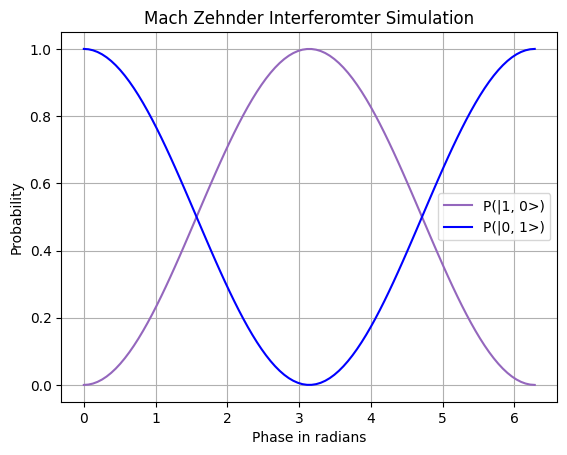

In [32]:
import numpy as np 
import matplotlib.pyplot as plt

# initialize states
input_state = BasicState([1, 0])
out0 = BasicState([1, 0])
out1 = BasicState([0, 1])

# phase sweep
phis = np.linspace(0, 2 * np.pi, 100)

# probabilities
p_out0 = []
p_out1 = []

for phi in phis:
    circuit = comp.Circuit(2)
    circuit.add(0, comp.BS())
    circuit.add(0, comp.PS(phi))
    circuit.add(0, comp.BS())

    backend = NaiveBackend()
    backend.set_circuit(circuit)
    backend.set_input_state(input_state)

    p0 = backend.probability(out0)
    p1 = backend.probability(out1)

    p_out0.append(p0)
    p_out1.append(p1)


plt.plot(phis, p_out0, label = 'P(|1, 0>)', color = 'tab:purple')
plt.plot(phis, p_out1, label = 'P(|0, 1>)', color = 'blue')
plt.xlabel('Phase in radians')
plt.ylabel('Probability')
plt.title('Mach Zehnder Interferomter Simulation')
plt.legend()
plt.grid(True)
plt.show()


### Sound Conversion

The sound should move from the left speaker to the right as the phase increases

In [37]:
from scipy.io.wavfile import write

sample_rate = 44100
duration = 4.0 # seconds
frequency = 440.0 # A4

time_audio_axis = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
time_probability_axis = np.linspace(0, duration, len(p_out0), endpoint=False)

# interpolation
left_env = np.interp(time_audio_axis, time_probability_axis, p_out0)
right_env = np.interp(time_audio_axis, time_probability_axis, p_out1)

tone = np.sin(2 * np.pi * frequency * time_audio_axis)

left = tone * left_env
right = tone * right_env

# turns the 1D column arrays into a 2D array
audio = np.column_stack((left, right))

# normalization
audio = audio / np.max(np.abs(audio))

audio_int16 = np.int16(audio * 32767)
write("interference.wav", sample_rate, audio_int16)
print("Saved interference.wav file")

Saved interference.wav file
